# Financial Inclusion in Africa — EDA

Анализ данных опроса о финансовой доступности в Африке.
Датасет и задача: [Zindi — Financial Inclusion in Africa](https://zindi.africa/competitions/financial-inclusion-in-africa)

Цель: понять, какие факторы (образование, местоположение, демография) связаны с наличием банковского счёта.

In [1]:
import pandas as pd
df = pd.read_csv('Desktop/financial-inclusion-in-africa20250311-22142-nbnoiv/Train.csv')
df.head()

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   country                 23524 non-null  object
 1   year                    23524 non-null  int64 
 2   uniqueid                23524 non-null  object
 3   bank_account            23524 non-null  object
 4   location_type           23524 non-null  object
 5   cellphone_access        23524 non-null  object
 6   household_size          23524 non-null  int64 
 7   age_of_respondent       23524 non-null  int64 
 8   gender_of_respondent    23524 non-null  object
 9   relationship_with_head  23524 non-null  object
 10  marital_status          23524 non-null  object
 11  education_level         23524 non-null  object
 12  job_type                23524 non-null  object
dtypes: int64(3), object(10)
memory usage: 2.3+ MB


In [3]:
df.describe()

,year,household_size,age_of_respondent
count,23524.000000,23524.000000,23524.000000
mean,2016.975939,3.797483,38.805220
std,0.847371,2.227613,16.520569
min,2016.000000,1.000000,16.000000
25%,2016.000000,2.000000,26.000000
50%,2017.000000,3.000000,35.000000
75%,2018.000000,5.000000,49.000000
max,2018.000000,21.000000,100.000000


In [4]:
df['bank_account'].value_counts()

bank_account
No     20212
Yes     3312
Name: count, dtype: int64

In [5]:
pd.crosstab(df['location_type'], df['bank_account'], normalize='index')

bank_account,No,Yes
location_type,,
Rural,0.883497,0.116503
Urban,0.821261,0.178739


In [6]:
pd.crosstab(df['location_type'], df['bank_account'], normalize='index')

bank_account,No,Yes
location_type,,
Rural,0.883497,0.116503
Urban,0.821261,0.178739


In [8]:
pd.crosstab(df['education_level'], df['bank_account'], normalize='index')

bank_account,No,Yes
education_level,,
No formal education,0.961019,0.038981
Other/Dont know/RTA,0.685714,0.314286
Primary education,0.914549,0.085451
Secondary education,0.767227,0.232773
Tertiary education,0.489196,0.510804
Vocational/Specialised training,0.429639,0.570361


In [9]:
df['education_level'].value_counts()

education_level
Primary education                  12791
No formal education                 4515
Secondary education                 4223
Tertiary education                  1157
Vocational/Specialised training      803
Other/Dont know/RTA                   35
Name: count, dtype: int64

In [10]:
counts = df['education_level'].value_counts()
percent_yes = pd.crosstab(df['education_level'], df['bank_account'], normalize='index')['Yes']

summary = pd.DataFrame({
    'total_people': counts,
    'share_with_account': percent_yes
})
summary

,total_people,share_with_account
education_level,,
No formal education,4515,0.038981
Other/Dont know/RTA,35,0.314286
Primary education,12791,0.085451
Secondary education,4223,0.232773
Tertiary education,1157,0.510804
Vocational/Specialised training,803,0.570361


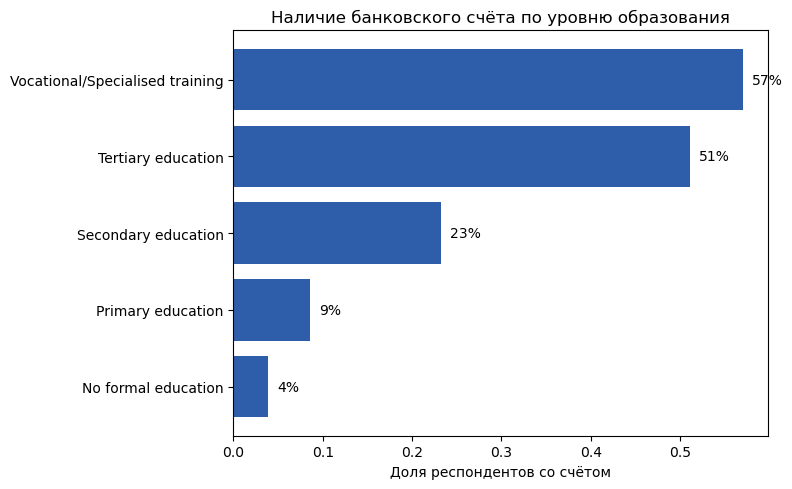

In [11]:
import matplotlib.pyplot as plt

chart_data = summary.drop('Other/Dont know/RTA').sort_values('share_with_account')

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(chart_data.index, chart_data['share_with_account'], color='#2E5EAA')
ax.set_xlabel('Доля респондентов со счётом')
ax.set_title('Наличие банковского счёта по уровню образования')
for i, v in enumerate(chart_data['share_with_account']):
    ax.text(v + 0.01, i, f'{v:.0%}', va='center')
plt.tight_layout()
plt.show()

## Выводы

- В выборке **86% респондентов не имеют банковского счёта** — финансовая доступность в целом низкая (сильный дисбаланс классов, важно учитывать при дальнейшем моделировании).
- **Уровень образования — самый сильный фактор**: доля людей со счётом растёт с 4% (без образования) до 57% (проф. подготовка) — разница в 14 раз.
- **Городская/сельская местность** тоже влияет, но слабее: в городе счёт есть у 17.9% людей против 11.7% в деревне (разница в ~1.5 раза).
- Категория "Other/Dont know/RTA" (35 человек) исключена из анализа образования как статистически ненадёжная из-за малого размера группы.